# XGBoost: Predict **log(C5)** or **C5** from deseason residuals / Lagged features

Defaults: features **`Transformed_Deseason_Residual_Browian.xlsx`** (fallback: **`Transformed_Deseason_Residuals_Lagged.xlsx`**); C5 master **`Master_Data_Base_version_Brownian_by_frequency.xlsx`** (fallback: **`Master_Data_AVG_version_update.xlsx`**). Override with env **`XGBOOST_FEATURES_XLSX`** / **`XGBOOST_MASTER_XLSX`** (basename under `BASE_DIR` or absolute path).

Outputs are tagged with **feature-source stem** and **master stem** so runs are distinguishable (does not overwrite the raw master filename).

Set **`USE_LOG_TARGET`** in the next configuration cell: **`True`** → target is **log(C5)** (and column **`log_C5_XGBoost_pred`**); **`False`** → target is **C5** in level (**`C5_XGBoost_pred`**). Autoregressive lags/rolls are built in the same space as the target.


In [1]:
# Optional: install xgboost if not present
# %pip install xgboost scikit-learn

In [2]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression
import xgboost as xgb


def _first_existing(candidates):
    """Resolve basename under BASE_DIR or absolute path."""
    for c in candidates:
        if not c:
            continue
        if os.path.isfile(c):
            return c
        p = os.path.join(BASE_DIR, c)
        if os.path.isfile(p):
            return p
    return None


# Path setup
BASE_DIR = os.getcwd()
_markers = (
    "Transformed_Deseason_Residual_Browian.xlsx",
    "Transformed_Deseason_Residuals_Lagged.xlsx",
    "Master_Data_Base_version_Brownian_by_frequency.xlsx",
)
if not any(os.path.isfile(os.path.join(BASE_DIR, m)) for m in _markers):
    BASE_DIR = os.path.expanduser("~/Downloads/Project 005 Data")
print(f"BASE_DIR: {BASE_DIR}")

_feat_cands = [
    os.environ.get("XGBOOST_FEATURES_XLSX"),
    "Transformed_Deseason_Residual_Browian.xlsx",
    "Transformed_Deseason_Residuals_Lagged.xlsx",
]
_master_cands = [
    os.environ.get("XGBOOST_MASTER_XLSX"),
    "Master_Data_Base_version_Brownian_by_frequency.xlsx",
    "Master_Data_AVG_version_update.xlsx",
]
FEATURES_PATH = _first_existing(_feat_cands)
MASTER_PATH = _first_existing(_master_cands)
if FEATURES_PATH is None:
    raise FileNotFoundError("No features workbook found. Tried: " + ", ".join(str(x) for x in _feat_cands if x))
if MASTER_PATH is None:
    raise FileNotFoundError("No master workbook found. Tried: " + ", ".join(str(x) for x in _master_cands if x))

FEATURES_INPUT_STEM = Path(FEATURES_PATH).stem
MASTER_INPUT_STEM = Path(MASTER_PATH).stem
OUTPUT_RUN_TAG = f"{FEATURES_INPUT_STEM}__master_{MASTER_INPUT_STEM}"
master_path = MASTER_PATH  # used by merge/save cells

print(f"FEATURES_PATH: {FEATURES_PATH}")
print(f"master_path:   {master_path}")
print(f"OUTPUT_RUN_TAG: {OUTPUT_RUN_TAG}")

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


BASE_DIR: /Users/andyyang/Downloads/Project 005 Data


In [3]:
# Train/test split: use holdout for evaluation
USE_OUT_OF_SAMPLE = True

# Target scale: True → log(C5) + log_C5_* AR features; False → C5 level + C5_* AR features
USE_LOG_TARGET = False
PRED_COL = "log_C5_XGBoost_pred" if USE_LOG_TARGET else "C5_XGBoost_pred"
AR_COLS = (
    ["log_C5_lag1", "log_C5_lag2", "log_C5_lag5", "log_C5_lag10", "log_C5_lag20", "log_C5_rolling5", "log_C5_rolling20"]
    if USE_LOG_TARGET
    else ["C5_lag1", "C5_lag2", "C5_lag5", "C5_lag10", "C5_lag20", "C5_rolling5", "C5_rolling20"]
)


In [4]:
# Load feature matrix (see FEATURES_PATH / FEATURES_INPUT_STEM in imports cell)
features_df = pd.read_excel(FEATURES_PATH)
features_df.columns = pd.Index(str(c) for c in features_df.columns)

# Exclude model-generated variables to avoid feature leakage/circular dependency
MODEL_GENERATED_PATTERNS = ["XGBoost_pred", "_pred"]  # extend as needed for other model outputs
exclude_cols = [c for c in features_df.columns if any(p in str(c) for p in MODEL_GENERATED_PATTERNS)]
if exclude_cols:
    features_df = features_df.drop(columns=exclude_cols)
    print(f"Excluded model-generated cols: {exclude_cols}")

# Set Date as index
date_col = "Date" if "Date" in features_df.columns else features_df.columns[0]
features_df[date_col] = pd.to_datetime(features_df[date_col])
features_df = features_df.set_index(date_col)

print(f"Features ({FEATURES_INPUT_STEM}): {features_df.shape[0]} rows, {features_df.shape[1]} cols")
features_df.head(2)

Features: 3653 rows, 354 cols


,China Manufacturing Purchasing Managers Index (Official)_PMI_season143d_ar21_lag_21,China Manufacturing Purchasing Managers Index (Official)_PMI_season143d_ar21_ma_63,Industrial Production China_% Yr/Yr_season190d_ar24_lag_63,Industrial Production China_% Yr/Yr_season190d_ar24_ma_63,Industrial Production Japan_% Yr/Yr_season171d_ar23_lag_1,Industrial Production Japan_% Yr/Yr_season171d_ar23_ma_63,Industrial Production S Korea_% Yr/Yr_season180d_ar24_lag_27,Industrial Production S Korea_% Yr/Yr_season180d_ar24_ma_49,"China Steel Production_,000 tonnes_season63d_ar24_lag_57","China Steel Production_,000 tonnes_season63d_ar24_ma_63",...,steel margin cash profit with cost delayed 1 week for marginal producer of CRC_season144d_ar1_lag_1,steel margin cash profit with cost delayed 1 week for marginal producer of CRC_season144d_ar1_ma_63,Guinea Total Bauxite Exports_season244d_ar24_lag_49,Guinea Total Bauxite Exports_season244d_ar24_ma_63,Guinea Bauxite Exports in Capes_season252d_ar24_lag_63,Guinea Bauxite Exports in Capes_season252d_ar24_ma_63,CHN Imports from Guinea_season243d_ar24_lag_7,CHN Imports from Guinea_season243d_ar24_ma_63,CHN Imports from Guinea inCapes_season252d_ar24_lag_1,CHN Imports from Guinea inCapes_season252d_ar24_ma_63
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
2013-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2013-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Load C5 master — build target (log C5 or level C5); master_path set in imports cell
master_df = pd.read_excel(master_path)

# Use Date column
mdate = "Date" if "Date" in master_df.columns else master_df.columns[0]
master_df[mdate] = pd.to_datetime(master_df[mdate])
master_df = master_df.set_index(mdate)

c5 = master_df["C5"].astype(float)
if USE_LOG_TARGET:
    target_series = np.log(c5.replace(0, np.nan)).dropna()
    _tgt_desc = "log(C5)"
else:
    target_series = c5.replace(0, np.nan).dropna()
    _tgt_desc = "C5"

# Keep 2015-2024 window (train/test split below uses 2015-2023 vs 2024)
target_series = target_series.loc[(target_series.index >= "2015-01-01") & (target_series.index <= "2025-12-31")]
print(f"Target {_tgt_desc}: {len(target_series)} rows")
target_series.head()


Target C5: 2870 rows


Date
2015-01-01    5.110
2015-01-02    4.994
2015-01-05    4.900
2015-01-06    4.741
2015-01-07    4.580
Name: C5, dtype: float64

In [6]:
# Align features and target on date index
common_idx = features_df.index.intersection(target_series.index)
X = features_df.loc[common_idx].copy()
y = target_series.loc[common_idx].copy()
X.columns = pd.Index(str(c) for c in X.columns)

# Drop rows with NaN in target
valid = y.notna()
X = X.loc[valid]
y = y.loc[valid]

# Fill remaining feature NaNs with 0 (XGBoost handles missing)
X = X.fillna(0)

# Autoregressive target features (past-only); avoid duplicate column names vs feature sheet
X = X.drop(columns=[c for c in AR_COLS if c in X.columns], errors="ignore")
ar_features = pd.DataFrame(
    {
        AR_COLS[0]: y.shift(1),
        AR_COLS[1]: y.shift(2),
        AR_COLS[2]: y.shift(5),
        AR_COLS[3]: y.shift(10),
        AR_COLS[4]: y.shift(20),
        AR_COLS[5]: y.rolling(5, min_periods=1).mean().shift(1),
        AR_COLS[6]: y.rolling(20, min_periods=1).mean().shift(1),
    },
    index=X.index,
)
X = pd.concat([X, ar_features], axis=1)

# Drop rows where AR features have NaN (first ~20 rows)
ar_valid = X[ar_features.columns].notna().all(axis=1)
X = X.loc[ar_valid]
y = y.loc[ar_valid]

# Fill any remaining AR NaNs with 0 (edge cases)
X = X.fillna(0)

print(f"Aligned (with AR features): X {X.shape}, y {y.shape}")


TypeError: unhashable type: 'list'

In [ ]:
# Train/test split (or full data for forward prediction without OOS holdout)
X = X.sort_index()
y = y.sort_index()

if USE_OUT_OF_SAMPLE:
    # Train: 2015-01-01 to 2023-12-31; Test: 3 months ahead = 2024-01-01 to 2024-03-31
    train_end = "2024-12-31"
    test_start = "2025-01-01"
    test_end = "2025-03-31"
    train_mask = (X.index >= "2015-01-01") & (X.index <= train_end)
    test_mask = (X.index >= test_start) & (X.index <= test_end)
    X_train, X_test = X.loc[train_mask], X.loc[test_mask]
    y_train, y_test = y.loc[train_mask], y.loc[test_mask]
    if len(X_train) == 0 or len(X_test) == 0:
        raise ValueError("Train or test split is empty. Check date coverage in X/y.")
    print(f"Train period: {X_train.index.min().date()} to {X_train.index.max().date()} | rows={len(X_train)}")
    print(f"Test period (3 months ahead): {X_test.index.min().date()} to {X_test.index.max().date()} | rows={len(X_test)}")
else:
    # Forward prediction: use full data (no out-of-sample holdout)
    X_train = X.copy()
    X_test = X.copy()
    y_train = y.copy()
    y_test = y.copy()
    train_end = X.index.max().strftime("%Y-%m-%d")  # for walk-forward CV
    print(f"Forward prediction mode: using full data | rows={len(X_train)}")

Train period: 2015-01-29 to 2023-12-29 | rows=2327
Test period (3 months ahead): 2024-01-01 to 2024-03-29 | rows=65


In [ ]:
# Feature Selection + Grid Search (time-series aware)
# Goal: reduce overfitting and improve out-of-sample R²

def mape(y_true, y_pred):
    mask = np.abs(y_true) > 1e-10
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


# AR_COLS defined with USE_LOG_TARGET (configuration cell)

def apply_feature_selection(method_name, X_tr, y_tr, X_te):
    """
    Returns transformed X_tr, X_te and metadata with selected feature names.
    """
    if method_name == "none":
        selected_cols = list(X_tr.columns)
        return X_tr.copy(), X_te.copy(), {"method": method_name, "selected_cols": selected_cols}

    if method_name == "variance_corr":
        # 1) Remove near-constant features
        vt = VarianceThreshold(threshold=1e-8)
        X_tr_v = pd.DataFrame(vt.fit_transform(X_tr), index=X_tr.index, columns=X_tr.columns[vt.get_support()])
        X_te_v = pd.DataFrame(vt.transform(X_te), index=X_te.index, columns=X_tr_v.columns)

        # 2) Remove very highly correlated features (train-only decision)
        corr = X_tr_v.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        drop_cols = [c for c in upper.columns if any(upper[c] > 0.98)]

        X_tr_f = X_tr_v.drop(columns=drop_cols)
        X_te_f = X_te_v.drop(columns=drop_cols)
        return X_tr_f, X_te_f, {"method": method_name, "selected_cols": list(X_tr_f.columns)}

    # kbest_40, kbest_60, kbest_80, kbest_f (120)
    if method_name.startswith("kbest_"):
        k_map = {"kbest_f": 120, "kbest_40": 40, "kbest_60": 60, "kbest_80": 80}
        k = k_map.get(method_name, 120)
        k = min(k, X_tr.shape[1])
        skb = SelectKBest(score_func=f_regression, k=k)
        X_tr_k = pd.DataFrame(skb.fit_transform(X_tr, y_tr), index=X_tr.index, columns=X_tr.columns[skb.get_support()])
        X_te_k = pd.DataFrame(skb.transform(X_te), index=X_te.index, columns=X_tr_k.columns)
        return X_tr_k, X_te_k, {"method": method_name, "selected_cols": list(X_tr_k.columns)}

    # ar_plus_kbest_60: always keep AR features + top 60 from non-AR
    if method_name.startswith("ar_plus_kbest_"):
        k = int(method_name.split("_")[-1])
        ar_cols_present = [c for c in AR_COLS if c in X_tr.columns]
        non_ar = [c for c in X_tr.columns if c not in AR_COLS]
        if len(non_ar) == 0:
            return X_tr.copy(), X_te.copy(), {"method": method_name, "selected_cols": list(X_tr.columns)}
        k_sel = min(k, len(non_ar))
        skb = SelectKBest(score_func=f_regression, k=k_sel)
        X_non_ar_tr = X_tr[non_ar]
        X_non_ar_te = X_te[non_ar]
        X_tr_sel = pd.DataFrame(skb.fit_transform(X_non_ar_tr, y_tr), index=X_tr.index, columns=X_non_ar_tr.columns[skb.get_support()])
        X_te_sel = pd.DataFrame(skb.transform(X_non_ar_te), index=X_te.index, columns=X_tr_sel.columns)
        X_tr_out = pd.concat([X_tr[ar_cols_present], X_tr_sel], axis=1)
        X_te_out = pd.concat([X_te[ar_cols_present], X_te_sel], axis=1)
        return X_tr_out, X_te_out, {"method": method_name, "selected_cols": list(X_tr_out.columns)}

    if method_name == "xgb_importance":
        temp_model = xgb.XGBRegressor(
            objective="reg:squarederror",
            n_estimators=300,
            learning_rate=0.03,
            max_depth=2,
            min_child_weight=15,
            subsample=0.7,
            colsample_bytree=0.6,
            gamma=0.3,
            reg_alpha=0.1,
            reg_lambda=5.0,
            random_state=42,
            n_jobs=1,
        )
        temp_model.fit(X_tr, y_tr)
        importances = pd.Series(temp_model.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
        selected_cols = list(importances.head(min(80, len(importances))).index)
        return X_tr[selected_cols].copy(), X_te[selected_cols].copy(), {"method": method_name, "selected_cols": selected_cols}

    raise ValueError(f"Unknown feature selection method: {method_name}")


# Regularized grid to reduce overfitting (shallower trees, stronger regularization)
param_grid = {
    "n_estimators": [300, 600],
    "learning_rate": [0.01, 0.03],
    "max_depth": [1, 2],
    "min_child_weight": [15, 25],
    "subsample": [0.6],
    "colsample_bytree": [0.5],
    "gamma": [0.3],
    "reg_alpha": [0.1],
    "reg_lambda": [5.0, 10.0],
}

fs_methods = ["kbest_40", "kbest_60", "kbest_80", "ar_plus_kbest_60", "variance_corr", "xgb_importance"]
results = []
model_store = {}

# Walk-forward: last 3 months of train as validation (mimics "3 months ahead" test scenario)
val_start = (pd.Timestamp(train_end) - pd.DateOffset(months=3)).strftime("%Y-%m-%d")
wf_train_mask = (X_train.index < val_start)
wf_val_mask = (X_train.index >= val_start) & (X_train.index <= train_end)
train_idx = np.where(wf_train_mask)[0]
val_idx = np.where(wf_val_mask)[0]
if len(train_idx) > 0 and len(val_idx) > 0:
    cv_splits = [(train_idx, val_idx)]
    print(f"Using walk-forward CV: train to {val_start}, val {val_start} to {train_end}")
else:
    cv_splits = TimeSeriesSplit(n_splits=4)
    print("Using TimeSeriesSplit (4 folds)")

for fs_name in fs_methods:
    X_tr_fs, X_te_fs, fs_meta = apply_feature_selection(fs_name, X_train, y_train, X_test)

    base_model = xgb.XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
    )

    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring="neg_mean_squared_error",
        cv=cv_splits,
        n_jobs=1,
        verbose=0,
    )

    grid_search.fit(X_tr_fs, y_train)
    best_model = grid_search.best_estimator_

    y_pred_train_fs = best_model.predict(X_tr_fs)
    y_pred_test_fs = best_model.predict(X_te_fs)

    # When no OOS holdout, Test = Train (same data) — report Test as NaN to avoid misleading metrics
    if USE_OUT_OF_SAMPLE:
        test_r2 = r2_score(y_test, y_pred_test_fs)
        test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test_fs))
        test_mae = mean_absolute_error(y_test, y_pred_test_fs)
        test_mape = mape(y_test.values, y_pred_test_fs)
    else:
        test_r2 = test_rmse = test_mae = test_mape = np.nan
    row = {
        "FeatureSet": fs_name,
        "N_Features": X_tr_fs.shape[1],
        "Best_CV_RMSE": np.sqrt(-grid_search.best_score_),
        "Train_R2": r2_score(y_train, y_pred_train_fs),
        "Test_R2": test_r2,
        "Train_RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train_fs)),
        "Test_RMSE": test_rmse,
        "Train_MAE": mean_absolute_error(y_train, y_pred_train_fs),
        "Test_MAE": test_mae,
        "Train_MAPE": mape(y_train.values, y_pred_train_fs),
        "Test_MAPE": test_mape,
        "Best_Params": grid_search.best_params_,
    }
    results.append(row)
    model_store[fs_name] = {"model": best_model, "meta": fs_meta, "params": grid_search.best_params_}

# Pick best by lowest test RMSE (you can switch to highest Test_R2 if preferred)
# When no OOS holdout, select best by CV RMSE; otherwise by Test RMSE
sort_col = "Best_CV_RMSE" if not USE_OUT_OF_SAMPLE else "Test_RMSE"
results_df = pd.DataFrame(results).sort_values(sort_col).reset_index(drop=True)

best_fs_name = results_df.loc[0, "FeatureSet"]
best_params = model_store[best_fs_name]["params"]
selected_feature_names = model_store[best_fs_name]["meta"]["selected_cols"]

# Build metrics table for the winning setup
winner = model_store[best_fs_name]
X_train_best, X_test_best, _ = apply_feature_selection(best_fs_name, X_train, y_train, X_test)
y_pred_train = winner["model"].predict(X_train_best)
y_pred_test = winner["model"].predict(X_test_best)

if USE_OUT_OF_SAMPLE:
    metrics = pd.DataFrame({
        "Train": {
            "R²": r2_score(y_train, y_pred_train),
            "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
            "MAE": mean_absolute_error(y_train, y_pred_train),
            "MAPE (%)": mape(y_train.values, y_pred_train),
        },
        "Test": {
            "R²": r2_score(y_test, y_pred_test),
            "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_test)),
            "MAE": mean_absolute_error(y_test, y_pred_test),
            "MAPE (%)": mape(y_test.values, y_pred_test),
        },
    }).T
else:
    metrics = pd.DataFrame({
        "In-sample": {
            "R²": r2_score(y_train, y_pred_train),
            "RMSE": np.sqrt(mean_squared_error(y_train, y_pred_train)),
            "MAE": mean_absolute_error(y_train, y_pred_train),
            "MAPE (%)": mape(y_train.values, y_pred_train),
        },
    }).T

print(f"Feature selection comparison (sorted by {sort_col})")
if USE_OUT_OF_SAMPLE:
    comparison_table = results_df[["FeatureSet", "N_Features", "Best_CV_RMSE", "Train_R2", "Test_R2", "Train_RMSE", "Test_RMSE"]].copy()
else:
    comparison_table = results_df[["FeatureSet", "N_Features", "Best_CV_RMSE", "Train_R2", "Train_RMSE"]].copy()
    comparison_table = comparison_table.rename(columns={"Train_R2": "In-sample R²", "Train_RMSE": "In-sample RMSE"})
print(comparison_table.to_string(index=False))

print(f"\nSelected best feature set: {best_fs_name}")
print("Best Params:", best_params)
_metrics_lbl = "log(C5)" if USE_LOG_TARGET else "C5"
print(f"XGBoost {_metrics_lbl} prediction metrics" + (" (forward prediction, no OOS holdout)" if not USE_OUT_OF_SAMPLE else ""))
print("=" * 50)
metrics

# ========== Selected variables for each optimal model ==========
print("\n" + "=" * 60)
print("Selected variables for each optimal model")
print("=" * 60)
MAX_VARS_TO_SHOW = 80  # truncate display for models with many features
for fs_name in results_df["FeatureSet"].tolist():
    cols = model_store[fs_name]["meta"]["selected_cols"]
    params = model_store[fs_name]["params"]
    n_total = len(cols)
    print(f"\n--- {fs_name} ({n_total} variables) ---")
    print(f"Best params: {params}")
    cols_to_show = cols[:MAX_VARS_TO_SHOW]
    for i, c in enumerate(cols_to_show, 1):
        print(f"  {i:3d}. {c}")
    if n_total > MAX_VARS_TO_SHOW:
        print(f"  ... and {n_total - MAX_VARS_TO_SHOW} more")


Using walk-forward CV: train to 2023-09-30, val 2023-09-30 to 2023-12-31
Feature selection comparison (sorted by Test_RMSE)
      FeatureSet  N_Features  Best_CV_RMSE  Train_R2  Test_R2  Train_RMSE  Test_RMSE
        kbest_60          60      0.068136  0.978566 0.876620    0.054546   0.068405
        kbest_40          40      0.069425  0.977124 0.876318    0.056351   0.068489
  xgb_importance          80      0.069448  0.977805 0.874480    0.055506   0.068996
ar_plus_kbest_60          67      0.068659  0.977385 0.870932    0.056029   0.069964
        kbest_80          80      0.072304  0.977650 0.866517    0.055699   0.071151
   variance_corr         318      0.077679  0.971167 0.850821    0.063265   0.075218

Selected best feature set: kbest_60
Best Params: {'colsample_bytree': 0.5, 'gamma': 0.3, 'learning_rate': 0.03, 'max_depth': 2, 'min_child_weight': 25, 'n_estimators': 600, 'reg_alpha': 0.1, 'reg_lambda': 5.0, 'subsample': 0.6}
XGBoost log(C5) Prediction Metrics

Selected variabl

In [ ]:
# Save selected features for every trained model; column header = method | n=… | Test_R²=…
feat_by_model = {}
for _, row in results_df.iterrows():
    fs = row["FeatureSet"]
    names = model_store[fs]["meta"]["selected_cols"]
    n_feat = int(row["N_Features"])
    tr2 = row["Test_R2"]
    r2_str = f"{float(tr2):.6f}" if pd.notna(tr2) else "NA"
    col_header = f"{fs} | n={n_feat} | Test_R2={r2_str}"
    feat_by_model[col_header] = names

max_rows = max(len(v) for v in feat_by_model.values())
export_dict = {"feature_index": list(range(1, max_rows + 1))}
for hdr, names in feat_by_model.items():
    export_dict[hdr] = names + [None] * (max_rows - len(names))

model_features_path = os.path.join(
    BASE_DIR, f"XGBoost_model_features_by_selection__from_{OUTPUT_RUN_TAG}.xlsx"
)
pd.DataFrame(export_dict).to_excel(model_features_path, index=False)
print(f"Saved: {model_features_path}")


In [ ]:
# (Feature importance visualization moved to bottom of notebook)

In [ ]:
# Retrain on full data using best feature-selection method + best grid-search params
X_full_train, X_full_apply, full_fs_meta = apply_feature_selection(best_fs_name, X, y, X)

model_full = xgb.XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=1,
)
model_full.fit(X_full_train, y)

# Predict on all aligned dates
y_pred_full = model_full.predict(X_full_apply)
pred_series = pd.Series(y_pred_full, index=X.index, name=PRED_COL)

# Keep names for importance table
model_feature_names = list(X_full_train.columns)


In [ ]:
# Load full master again (preserve all columns)
master_full = pd.read_excel(master_path)

# Ensure Date column for merge
mdate = "Date" if "Date" in master_full.columns else master_full.columns[0]
master_full[mdate] = pd.to_datetime(master_full[mdate])

# Drop existing prediction column if present (avoids _x/_y suffixes on re-run)
pred_col = PRED_COL
if pred_col in master_full.columns:
    master_full = master_full.drop(columns=[pred_col])

# Map predictions to master by date
pred_df = pred_series.reset_index()
pred_df.columns = [mdate, pred_col]

# Merge: add prediction column where dates match
master_full = master_full.merge(pred_df, on=mdate, how="left")

# Save updated Excel (new filename — tags feature source + master)
out_path = os.path.join(
    BASE_DIR,
    f"{MASTER_INPUT_STEM}_with_{PRED_COL}__feat_{FEATURES_INPUT_STEM}.xlsx",
)
master_full.to_excel(out_path, index=False)
print(f"Updated: {out_path}")
print(f"Added column: {pred_col} ({master_full[pred_col].notna().sum()} non-null)")


Updated: /Users/andyyang/Downloads/Project 005 Data/Master_Data_AVG_version_update.xlsx
Added column: log_C5_XGBoost_pred (2589 non-null)


In [ ]:
# Optional: show top feature importances (for selected feature set)
imp = pd.DataFrame({
    "feature": model_feature_names,
    "importance": model_full.feature_importances_
}).sort_values("importance", ascending=False)
print(f"Top 15 feature importances (feature set: {best_fs_name}):")
print(imp.head(15).to_string(index=False))

Top 15 feature importances (feature set: kbest_60):
                                                                              feature  importance
                                                                     log_C5_rolling20    0.343397
                                                                          log_C5_lag2    0.163104
                                                                          log_C5_lag1    0.157373
                                                                      log_C5_rolling5    0.136176
                                                                          log_C5_lag5    0.127303
                                                                         log_C5_lag20    0.036975
                                       2 Month FFA Route Average_season10d_ar30_ma_63    0.013741
                                                   C3 1 Mon FFA_season261d_ar23_ma_63    0.010367
                                       1 Month FFA Route Average_s

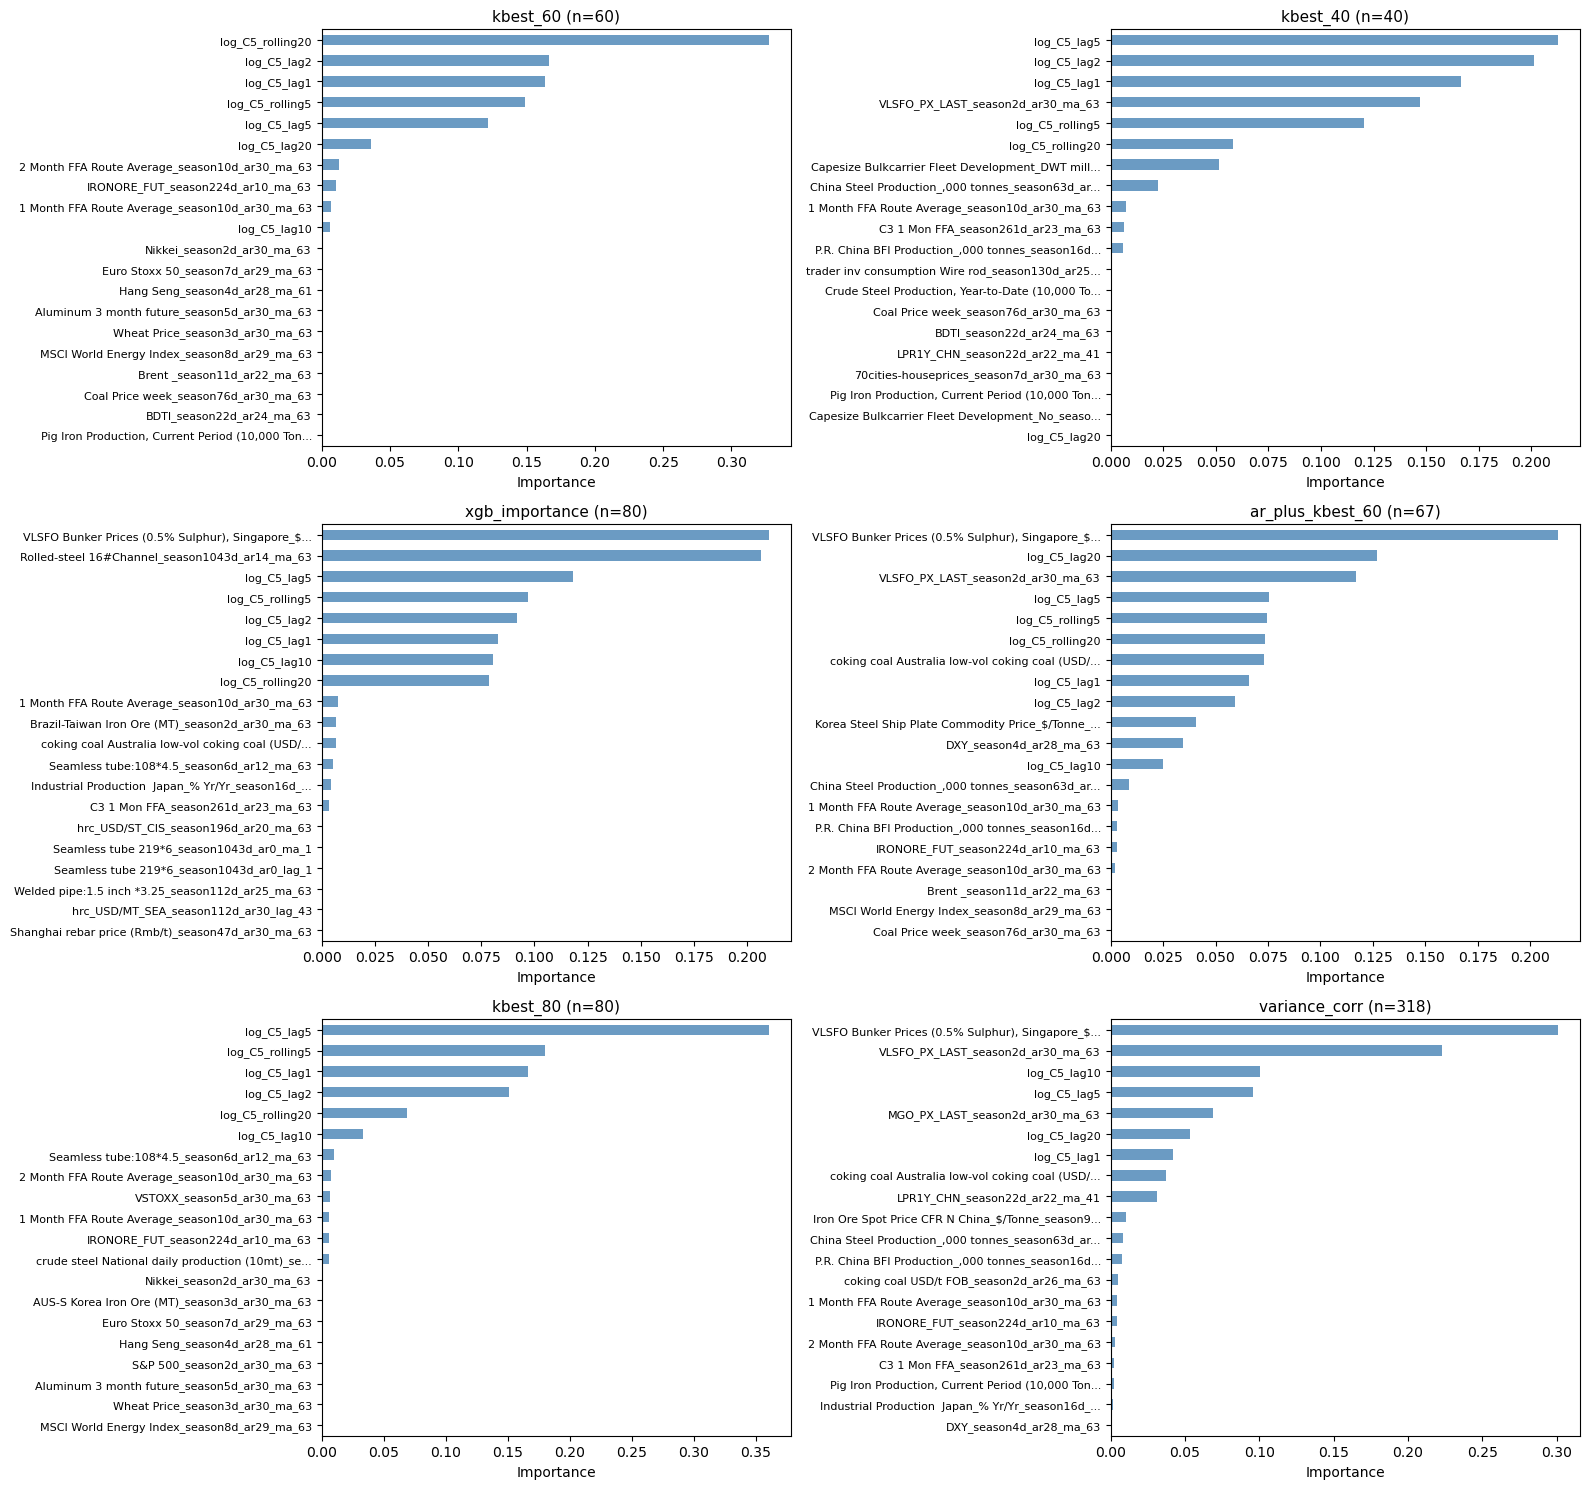

In [ ]:
# Feature importance visualization for each optimal model
N_TOP = 20  # top N features to show per model
n_models = len(model_store)
n_cols = 2
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
axes = np.atleast_2d(axes)

for idx, fs_name in enumerate(results_df["FeatureSet"].tolist()):
    row, col = idx // n_cols, idx % n_cols
    ax = axes[row, col]
    model = model_store[fs_name]["model"]
    cols = model_store[fs_name]["meta"]["selected_cols"]
    imp = pd.Series(model.feature_importances_, index=cols).sort_values(ascending=True)
    imp_top = imp.tail(N_TOP)
    # Truncate long labels for readability
    imp_top.index = [s[:47] + "..." if len(s) > 50 else s for s in imp_top.index]
    imp_top.plot(kind="barh", ax=ax, color="steelblue", alpha=0.8)
    ax.set_title(f"{fs_name} (n={len(cols)})", fontsize=11)
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=8)

# Hide unused subplots
for idx in range(n_models, n_rows * n_cols):
    row, col = idx // n_cols, idx % n_cols
    axes[row, col].set_visible(False)

plt.tight_layout()
plt.show()